In [6]:
# All imports
from Imports import *
from Helper import *
from Preprocessing import *
from Plotting import *
%matplotlib inline

In [7]:
# Load dataset and device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
jet_images_path = '../data/jet-images_Mass60-100_pT250-300_R1.25_Pix25.hdf5'
jet_mass_data = HDF5File(jet_images_path, 'r')

print(jet_mass_data.keys())
print(jet_mass_data['image'].shape)

<KeysViewHDF5 ['image', 'jet_delta_R', 'jet_eta', 'jet_mass', 'jet_phi', 'jet_pt', 'signal', 'tau_1', 'tau_2', 'tau_21', 'tau_3', 'tau_32']>
(872666, 25, 25)


In [8]:
# Generator
class Generator(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()
        self.latent_dim = latent_dim

        self.noise = GaussianNoise(sigma=0.1)

        self.feature_gen = nn.Sequential(
            nn.Linear(9, 64),
            nn.ReLU(True),
            nn.Linear(64, 256),
            nn.LayerNorm(256),
            self.noise
        )

        self.image_gen = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),  # 1x1 → 2x2
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.Dropout(0.2),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),   # 2x2 → 4x4
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.Dropout(0.2),

            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),     # 4x4 → 8x8
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            nn.Dropout(0.2),

            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),     # 8x8 → 16x16
            nn.Sigmoid()
        )

    def forward(self, z_feat):
        img = self.feature_gen(z_feat)
        # print(img.shape)
        img = img.view(-1, 256, 1, 1)
        # print(img.shape)
        img = self.image_gen(img)
        # print(img.shape)
        img = soft_threshold(img, threshold=0.001, sharpness=1000.0)
        return img

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Flattened image: 16x16 = 256
        self.image_encoder = nn.Sequential(
            spectral_norm(nn.Conv2d(1, 64, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.2),
            spectral_norm(nn.Conv2d(64, 128, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.2),
            spectral_norm(nn.Conv2d(128, 256, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.2),
            nn.Flatten()
        )

        self.feature_encoder = nn.Sequential(
            nn.Linear(4, 64),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(64, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
        )

        # Dynamically get input dimensions
        with torch.no_grad():
            dummy = torch.zeros(1, 1, 16, 16)
            flat_dim = self.image_encoder(dummy).shape[1] + 128

        # Combined classifier
        self.classifier = nn.Sequential(
            nn.Linear(flat_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(256, 64),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, img, features):
        img_encoded = self.image_encoder(img)
        feat_encoded = self.feature_encoder(features)
        combined = torch.cat((img_encoded, feat_encoded), dim=1)

        # print(img_encoded.shape)
        # print(feat_encoded.shape)
        # print(combined.shape[-1])

        prob = self.classifier(combined)

        return prob  # Shape: (batch_size, 1)

In [9]:
# Define variable and dataset
batch_size = 256
n_events = int(.1 * jet_mass_data['image'].shape[0])

latent_dim = 256
lr = 1e-3
n_epochs = 100
num = 4

dataset = JetDataset(jet_mass_data, n_events)
smote_dataset = JetDataset(jet_mass_data, int(.1*n_events))

real_data = smote_dataset.features   # pretend dataset
minority = smotenc_oversample(real_data, n_samples= n_events, categorical_features=[0])
minority = torch.tensor(minority, dtype=torch.float32)

dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)
sampleloader = DataLoader(minority, batch_size=batch_size, shuffle=True, drop_last=True)

print("Number of samples:", len(dataset))
print("Image shape:", dataset.images.shape)
print("Feature shape:", dataset.features.shape)

Image shape: torch.Size([87266, 16, 16])
dR Mean: torch.Size([87266])
dR STD: torch.Size([87266])
Pixel Mean: torch.Size([87266])
Pixel STD: torch.Size([87266])
ΔR min: 0.0
ΔR max: 2.203810453414917
ΔR mean min: 0.003941118251532316
ΔR mean max: 0.0156550332903862
ΔR std min: 0.020212490111589432
ΔR std max: 0.14540068805217743
Weights (pixel intensity) min: 0.0
Weights (pixel intensity) max: 1.0
Pixel mean min: 0.0028264394495636225
Pixel mean max: 0.00432002916932106
Pixel std min: 0.009188652969896793
Pixel std max: 0.06249340996146202
Image shape: torch.Size([8726, 16, 16])
dR Mean: torch.Size([8726])
dR STD: torch.Size([8726])
Pixel Mean: torch.Size([8726])
Pixel STD: torch.Size([8726])
ΔR min: 0.0
ΔR max: 2.0372369289398193
ΔR mean min: 0.00444405060261488
ΔR mean max: 0.014574162662029266
ΔR std min: 0.022066839039325714
ΔR std max: 0.1351994276046753
Weights (pixel intensity) min: 0.0
Weights (pixel intensity) max: 1.0
Pixel mean min: 0.0029388333205133677
Pixel mean max: 0.004

In [10]:
# Initialize models
generator = Generator(latent_dim).to(device)
discriminator = Discriminator().to(device)

optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.9, 0.999))
optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(0.9, 0.999))

scheduler_G = CosineAnnealingLR(optimizer_G, T_max=n_epochs, eta_min=1e-4)
scheduler_D = CosineAnnealingLR(optimizer_D, T_max=n_epochs, eta_min=1e-4)

g_losses = []
d_losses = []

# Tracking buffers
stats_dict = {
    'fake_dR_mean': [],
    'fake_dR_std': [],
    'fake_pixel_mean': [],
    'fake_pixel_std': [],
    'real_dR_mean': [],
    'real_dR_std': [],
    'real_pixel_mean': [],
    'real_pixel_std': []
}

dists = compute_distance_map(16,16).to(device)

params_G = sum(p.numel() for p in generator.parameters() if p.requires_grad)
print(f"Generator Params: {params_G}")

params_D = sum(p.numel() for p in discriminator.parameters() if p.requires_grad)
print(f"Discriminator Params: {params_D}")
print(f"Total Params: {params_D+params_G}")

Generator Params: 707105
Discriminator Params: 976705
Total Params: 1683810


In [15]:
## Load a previous model
load = False

if load:
    load_path = "models/smote_model_temp.pt" # Path to load your model
    # load_path = "models/class_gan_model_m21_1003.pt"  # Sample model
    
    # Load the checkpoint
    checkpoint = torch.load(load_path)
    
    # Restore model weights
    generator.load_state_dict(checkpoint["generator_state_dict"])
    discriminator.load_state_dict(checkpoint["discriminator_state_dict"])
    
    # Optionally restore tracking data
    g_losses = checkpoint["g_losses"]
    d_losses = checkpoint["d_losses"]
    
    stats_dict = checkpoint["stats_dict"]
    
    print(f"Loaded model from {load_path}")

[Epoch 1/20] [D loss: 0.6931] [G loss: 0.6317] [Validity_loss: 0.5536] 
 [Stat_loss: 0.0252] [NNZ_loss: 0.0529]
Sample feature coding: [1.         0.67980105 0.46313295 0.49320826 0.30920893 0.01013959
 0.03518034 0.00381765 0.01425803]


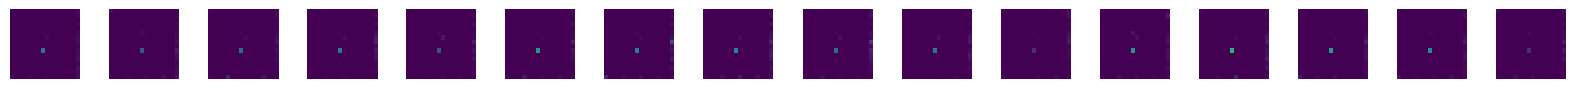

Model and statistics saved to models/class_gan_model_temp.pt


KeyboardInterrupt: 

In [27]:
# Training loop
if True:
    for epoch in range(n_epochs):
        for i, (real_image, real_features, flipped_image, flipped_features) in enumerate(dataloader):
            
            # All real data are normalized in the dataloader
            real_feat = real_features.to(device)
            real_flipped_feat = flipped_features.to(device)
            real_img = real_image.unsqueeze(1).to(device)
            real_flipped_img = flipped_image.unsqueeze(1).to(device)
    
            # print(f"Real: {real_img.shape}")
    
            # Codings will be label, eta, pT, mass that get passed directly to the discriminator
            # All feature values get passed to the generator, then the output image passed to the discriminator
    
            # Discriminator training
            if i % 3 == 0:
                optimizer_D.zero_grad()
                discriminator.train()
                # Generate fake samples
                z_codings = next(iter(sampleloader)).to(device)
                z_codings = z_codings.to(dtype=torch.float32, device=device)

                # Generate the fake image
                fake_img = generator(z_codings)
                # print(f"Fake: {fake_img.shape}")
    
                # Generate eta-flipped data
                flipped_z_codings = z_codings.clone()
                flipped_z_codings[:, 1] *= -1

                fake_flipped_img = generator(flipped_z_codings)
    
                # Get predictions and labels
                real_disc_codings = real_feat[:,:num]
                real_flipped_disc_codings = real_flipped_feat[:,:num]
                fake_disc_codings = z_codings[:,:num]
                fake_flipped_disc_codings = flipped_z_codings[:,:num]

                # Discriminator gets codings + image
                real_pred = discriminator(real_img, real_disc_codings)
                real_flipped_pred = discriminator(real_flipped_img, real_flipped_disc_codings)
                fake_pred = discriminator(fake_img, fake_disc_codings)
                fake_flipped_pred = discriminator(fake_flipped_img, fake_flipped_disc_codings)
    
                preds = (torch.cat([real_pred, real_flipped_pred, fake_pred, fake_flipped_pred], dim=0)).squeeze(1)

                # Labels
                ones = torch.ones(2*len(fake_pred))
                zeros = torch.zeros(2*len(real_pred))
                labels = (torch.cat([ones, zeros], dim=0)).to(device)
    
                # Discriminator loss is just its ability to distinguish
                d_loss = torch.nn.BCELoss()(preds, labels)

                d_loss.backward()
                
                optimizer_D.step()
    
            # Generator Training
            if i % 1 == 0:
                optimizer_G.zero_grad()
                generator.train()
                
                # Generate fake data
                # Should be very easy to modify which values are passed as codings
                z_codings = next(iter(sampleloader))
                z_codings = z_codings.to(dtype=torch.float32, device=device)
    
                # Generate image
                fake_img = generator(z_codings)
    
                # Generate eta-flipped data
                flipped_z_codings = z_codings.clone()
                flipped_z_codings[:, 1] *= -1

                fake_flipped_img = generator(flipped_z_codings)

                ## BCE Discriminator Loss
                # Discriminator gets codings + generated image
                fake_disc_codings = z_codings[:,:num]
                fake_flipped_disc_codings = flipped_z_codings[:,:num]

                # Get predictions and labels
                fake_pred = discriminator(fake_img, fake_disc_codings)
                fake_flipped_pred = discriminator(fake_flipped_img, fake_flipped_disc_codings)

                target = torch.ones_like(fake_pred)
                bce = nn.BCELoss()
                validity_loss = bce(fake_pred, target) + bce(fake_flipped_pred, target)
    
                ## Stat loss
                # Compute statistics for original and flipped fake images
                fake_stats_orig = compute_fake_statistics(fake_img.to('cpu'), dists.to('cpu'))
                fake_stats_flip = compute_fake_statistics(fake_flipped_img.to('cpu'), dists.to('cpu'))
                
                # Average the statistics
                fake_stats = {
                    'fake_dR_mean': 0.5 * (fake_stats_orig['fake_dR_mean'] + fake_stats_flip['fake_dR_mean']),
                    'fake_dR_std': 0.5 * (fake_stats_orig['fake_dR_std'] + fake_stats_flip['fake_dR_std']),
                    'fake_pixel_mean': 0.5 * (fake_stats_orig['fake_pixel_mean'] + fake_stats_flip['fake_pixel_mean']),
                    'fake_pixel_std': 0.5 * (fake_stats_orig['fake_pixel_std'] + fake_stats_flip['fake_pixel_std']),
                }
                
                # Move to device
                fake_dR_mean = fake_stats['fake_dR_mean'].to(device)
                fake_dR_std = fake_stats['fake_dR_std'].to(device)
                fake_pixel_mean = fake_stats['fake_pixel_mean'].to(device)
                fake_pixel_std = fake_stats['fake_pixel_std'].to(device)
                
                # Get real stats from z_codings (features 5–8)
                real_dR_mean = z_codings[:,5]
                real_dR_std = z_codings[:,6]
                real_pixel_mean = z_codings[:,7]
                real_pixel_std = z_codings[:,8]
                
                real_stats = {
                    'real_dR_mean': real_dR_mean,
                    'real_dR_std': real_dR_std,
                    'real_pixel_mean': real_pixel_mean,
                    'real_pixel_std': real_pixel_std
                }
                

                stat_loss = torch.nn.L1Loss()(real_dR_mean, fake_dR_mean) / .004
                stat_loss += torch.nn.L1Loss()(real_dR_std, fake_dR_std) / .025
                stat_loss += torch.nn.L1Loss()(real_pixel_mean, fake_pixel_mean) / .003
                stat_loss += torch.nn.L1Loss()(real_pixel_std, fake_pixel_std) / .03
                stat_loss /= 4

                ## Number non-zero loss
                fake_nnz = soft_count_nonzero(fake_img, threshold=3e-3, sharpness=10000.0)
                real_nnz = soft_count_nonzero(real_img, threshold=3e-3, sharpness=10000.0)
                nnz_loss = torch.nn.MSELoss()(fake_nnz, real_nnz)

                # Total generator loss is the average of the discriminator's predictions of the original and flipped data
                # + number of non-zero pixels loss
                # + the difference between input and output dR and pixel statistics
    
                alpha = .45
                beta = .035
                chi = .02
    
                g_loss = (alpha*validity_loss + beta*nnz_loss + chi*stat_loss)

                g_loss.backward()
                optimizer_G.step()
    
        g_losses.append(g_loss.item())
        d_losses.append(d_loss.item())

        print(f"[Epoch {epoch+1}/{n_epochs}] [D loss: {d_losses[-1]:.4f}] [G loss: {g_losses[-1]:.4f}] [Validity_loss: {alpha*validity_loss:.4f}] \n [Stat_loss: {chi*stat_loss:.4f}] [NNZ_loss: {beta*nnz_loss:.4f}]") 

        plot_smote_samples(generator, dataset, sampleloader, batch_size=16, latent_dim=256)

        if epoch % 10 == 0:
            # Save model states and tracked data in a temp file during training
            save_path = f"models/class_gan_model_temp.pt"
            torch.save({
                "generator_state_dict": generator.state_dict(),
                "discriminator_state_dict": discriminator.state_dict(),
                "g_losses": g_losses,
                "d_losses": d_losses,
                "stats_dict": stats_dict
            }, save_path)

            print(f"Model and statistics saved to {save_path}")

In [19]:
## Save Model
# Create output directory if it doesn't exist

save = True

if save:
    os.makedirs("models", exist_ok=True)

    # Timestamp for unique filenames
    timestamp = datetime.now().strftime("%m%d_%H%M")
    
    # Save model states and tracked data in a single file
    save_path = f"models/class_gan_model_1_{timestamp}.pt"
    torch.save({
        "generator_state_dict": generator.state_dict(),
        "discriminator_state_dict": discriminator.state_dict(),
        "g_losses": g_losses,
        "d_losses": d_losses,
        "stats_dict": stats_dict
    }, save_path)
    
    print(f"Model and statistics saved to {save_path}")

Model and statistics saved to models/class_gan_model_1_0920_1340.pt


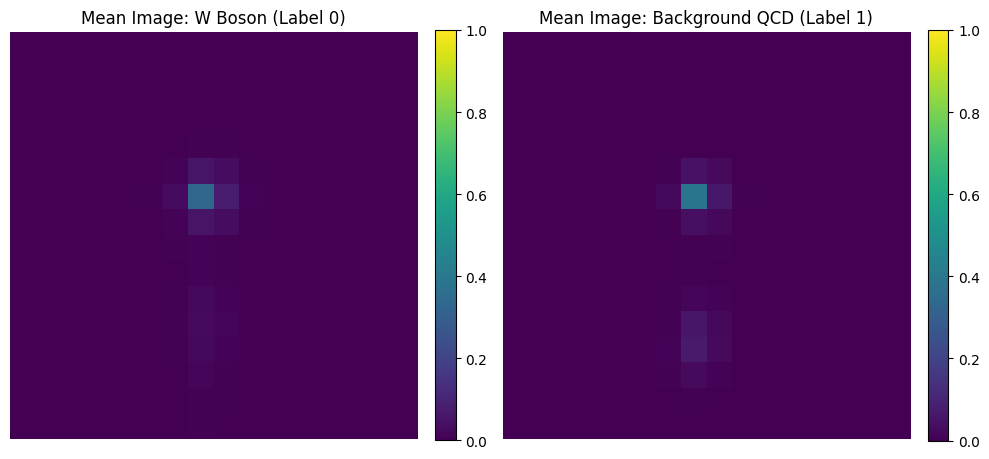

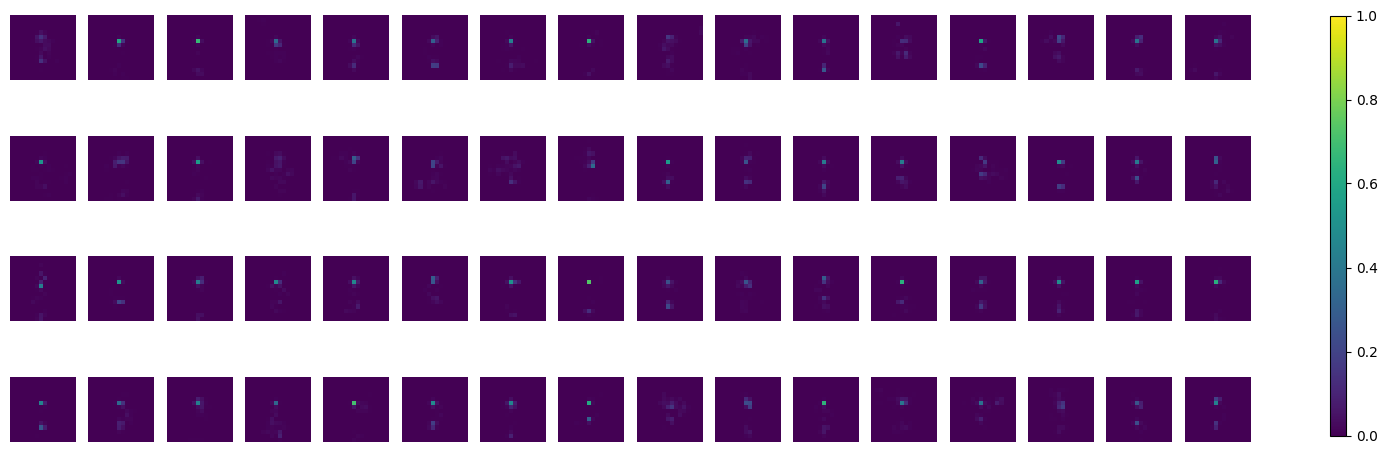

In [20]:
plot_real_samples(dataset)

In [21]:
## Load a previous model
load = True

if load:
    # load_path = "models/smote_model_0922_1734.pt" # Path to load your model
    # load_path = "models/class_gan_model_1_0922_1732.pt" # Path to load your model
    # load_path = "models/smote_model_0922_1503.pt" # Path to load your model
    # load_path = "models/smote_gan_model_1_0923_2217.pt" # Path to load your model
    # load_path = "models/smote_model_0923_2235.pt" # Path to load your model
    # load_path = "models/smote_model_0924_1646.pt" # Path to load your model
    # load_path = "models/smote_gan_model_1_0924_1605.pt" # Path to load your model

    # load_path = "models/smote_model_0927_1923.pt" # Path to load your model
    # load_path = "models/smote_model_temp.pt"  # Sample model
    # load_path = "models/smote_gan_model_temp.pt"  # Sample model
    load_path = "models/smote_model_0925_1825.pt"  # Sample model
    
    # Load the checkpoint
    checkpoint = torch.load(load_path)
    
    # Restore model weights
    generator.load_state_dict(checkpoint["generator_state_dict"])
    discriminator.load_state_dict(checkpoint["discriminator_state_dict"])
    
    # Optionally restore tracking data
    g_losses = checkpoint["g_losses"]
    d_losses = checkpoint["d_losses"]
    
    stats_dict = checkpoint["stats_dict"]
    
    print(f"Loaded model from {load_path}")

Loaded model from models/smote_model_0925_1825.pt


/global/u1/w/webbj/ICLR/GANS/Plotting.py:381: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  z_codings = torch.tensor(z_codings, dtype=torch.float32).to(next(generator.parameters()).device)


Sample feature coding: [1.         0.03455371 0.7611133  0.4925355  0.6065568  0.01124828
 0.0687833  0.00419019 0.02774558]


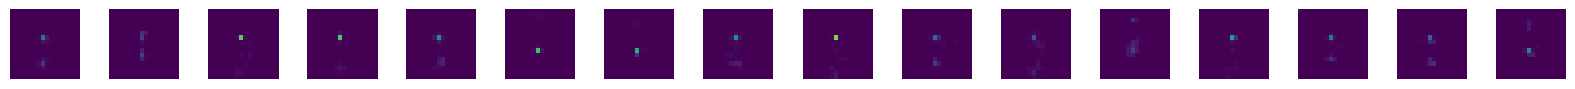

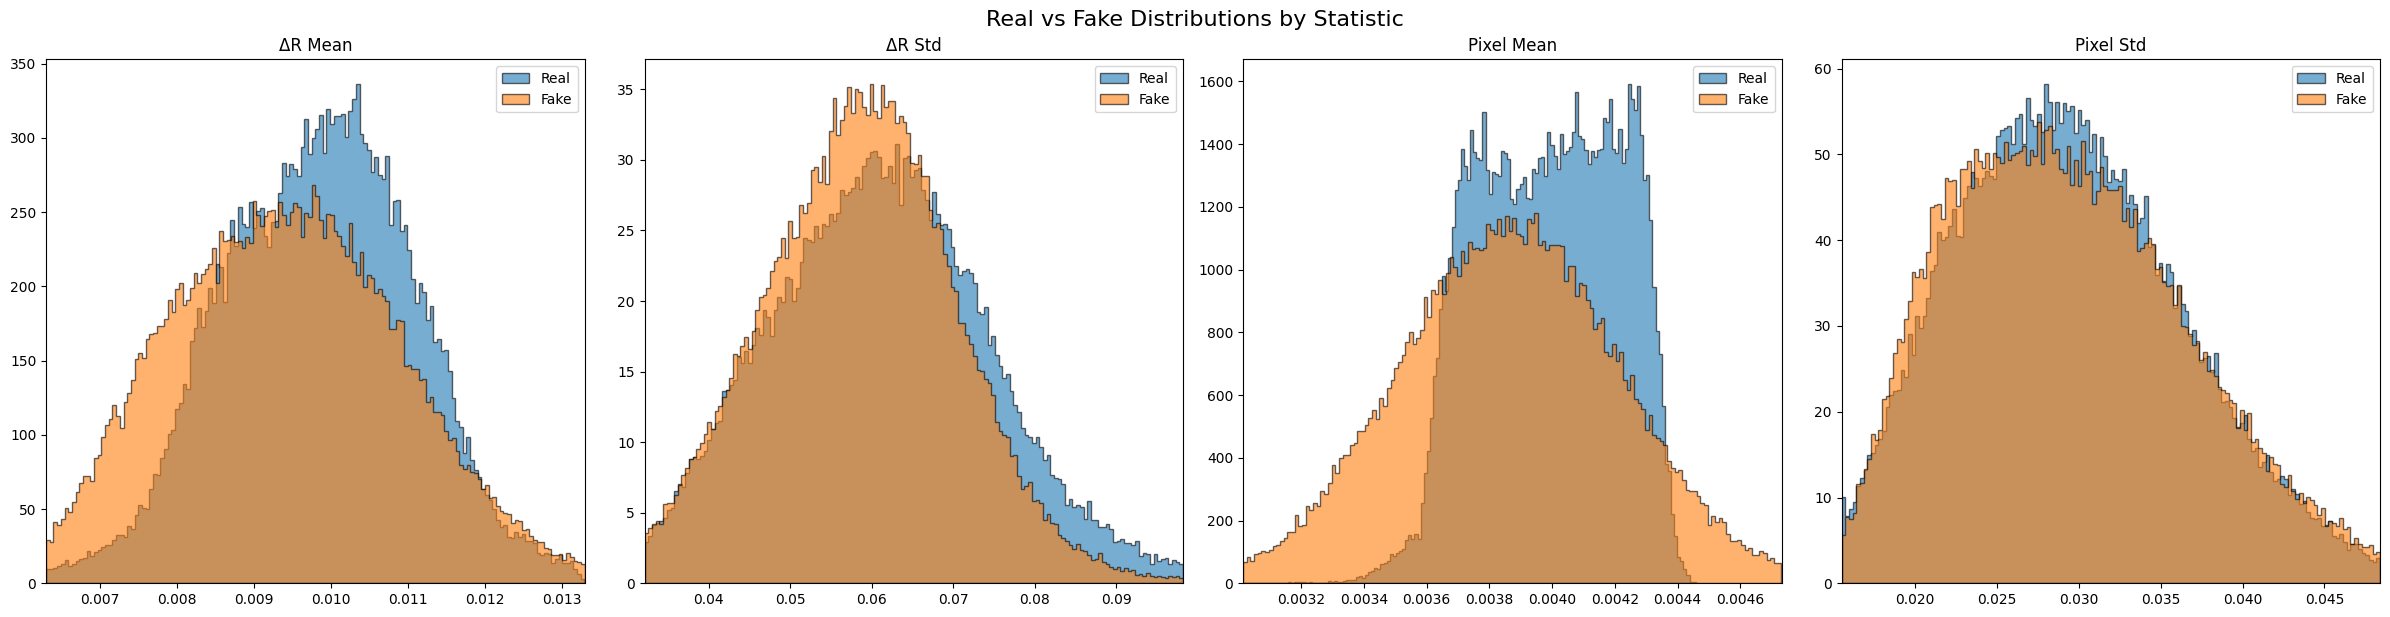

Discriminator output (wrong label): [0.9998871  0.98674065 0.8957694  ... 0.99441    1.         0.998317  ]
Discriminator output (correct label): [0.99828595 0.3755153  0.05981282 ... 0.7049112  1.         0.20109092]
Real labels: [1. 1. 1. ... 1. 1. 1.]
Swapped labels: [0. 0. 0. ... 0. 0. 0.]
Relative change (%): [1.6039610e-01 1.6276974e+02 1.3976211e+03 ... 4.1068840e+01 0.0000000e+00
 3.9645056e+02]


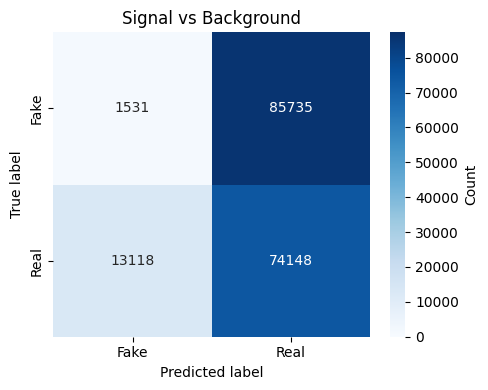

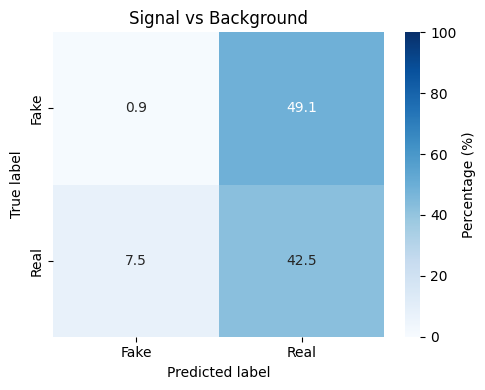

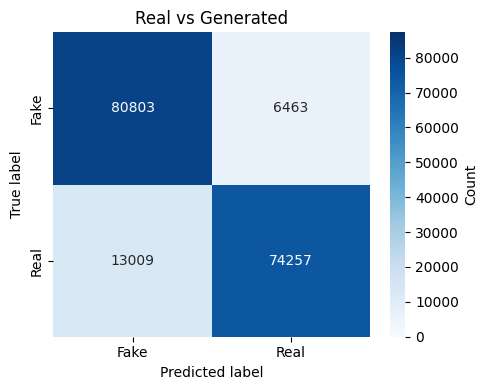

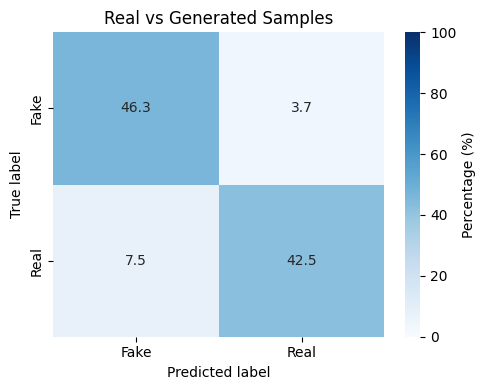

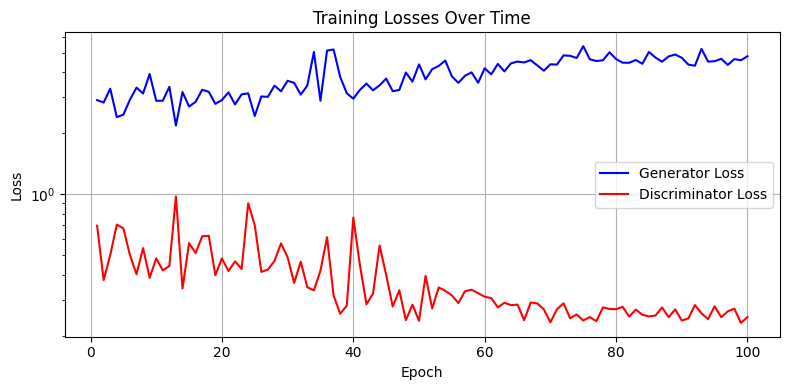

In [22]:
test_smote_samples(generator, discriminator, dataset, minority, batch_size=87266)

# Optional args:
#     generator,
#     discriminator,
#     dataset,
#     kdes,
#     batch_size=16,
#     latent_dim=256,
#     codings=None,
#     plot_distributions=True,
#     compare_discriminator=True

plot_metrics(g_losses, d_losses)

In [ ]:
%config InlineBackend.figure_format = 'retina'

import matplotlib.pyplot as plt
plt.rcParams.update({
    "figure.dpi": 150,
    "font.size": 20,
    "axes.titlesize": 22,
    "axes.labelsize": 20
})
kdes = feature_distributions(dataset)
test_generated_samples(generator, discriminator, dataset, kdes, batch_size=100000)

In [8]:
def test_smote_samples(
    generator,
    discriminator,
    dataset,
    minority,
    batch_size=16,
    latent_dim=256,
    codings=None,
    plot_distributions=True,
    compare_discriminator=True
):
    
    

    # Latent vectors
    z_codings = minority[:batch_size]
    z_codings = torch.tensor(z_codings, dtype=torch.float32).to(next(generator.parameters()).device)

    z_feat = z_codings

    with torch.no_grad():
        gen_samples = generator(z_codings)

    gen_samples = gen_samples.to('cpu')

    print("Sample feature coding:", z_codings[1].to('cpu').numpy())
    
    vmin = dataset.images.min()
    vmax = dataset.images.max()
    fig, axes = plt.subplots(1, min(batch_size, 16), figsize=(min(batch_size, 16), 1))
    
    for i in range(min(batch_size, 16)):
        n = torch.randint(batch_size, ())
        axes[i].imshow(gen_samples[n, 0].numpy(), cmap='viridis', vmin=vmin, vmax=vmax)
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

    if plot_distributions:
        dists = compute_distance_map(16, 16)
        fake_stats = compute_fake_statistics(gen_samples, dists)

        # Get real stats from z_codings (features 5–8)
        real_dR_mean = z_codings[:,5]
        real_dR_std = z_codings[:,6]
        real_pixel_mean = z_codings[:,7]
        real_pixel_std = z_codings[:,8]
    
        real_stats = {
            'real_dR_mean': real_dR_mean,
            'real_dR_std': real_dR_std,
            'real_pixel_mean': real_pixel_mean,
            'real_pixel_std': real_pixel_std
        }
        stats = track_statistics(fake_stats, real_stats)
        plot_tracked_statistics(stats)

    if compare_discriminator:
        n_events = batch_size
        real_features = dataset.features[:int(n_events/2), :4].clone()
        real_features = torch.cat([real_features, dataset.features[int(-n_events/2):, :4].clone()], 0)
        real_imgs = dataset.images[:int(n_events/2)].clone()
        real_imgs = torch.cat([real_imgs, dataset.images[int(-n_events/2):].clone()], 0)
        real_labels = real_features[:, 0]

        test_features = real_features.clone()
        test_labels = torch.zeros_like(real_labels)
        test_features[:, 0] *= (-2**(test_features[:, 0])+2)
        with torch.no_grad():
            pred1 = discriminator(real_imgs.unsqueeze(1).to('cuda'), test_features.to('cuda')).detach()
            pred2 = discriminator(real_imgs.unsqueeze(1).to('cuda'), real_features.to('cuda')).detach()

        print("Discriminator output (wrong label):", pred1.squeeze().to('cpu').numpy())
        print("Discriminator output (correct label):", pred2.squeeze().to('cpu').numpy())
        print("Real labels:", real_labels.numpy())
        print("Swapped labels:", test_features[:, 0].numpy())
        print("Relative change (%):", ((pred1 / pred2 - 1) * 100).squeeze().to('cpu').numpy())

        # Confusion matrix for real data, wrong label
        # Threshold predictions
        # pred1 = discriminator(real_imgs, fake_labels) → expect 0
        # pred2 = discriminator(real_imgs, true_labels) → expect 1
        pred1_binary = (pred1.to('cpu').numpy() >= 0.5).astype(int).squeeze()
        pred2_binary = (pred2.to('cpu').numpy() >= 0.5).astype(int).squeeze()
        
        # Create true labels
        true_labels = np.concatenate([np.zeros_like(pred1_binary), np.ones_like(pred2_binary)])
        predicted_labels = np.concatenate([pred1_binary, pred2_binary])

        # Confusion matrix
        cm = confusion_matrix(true_labels, predicted_labels)
        plot_confusion_matrix(cm, ["Fake", "Real"], "Signal vs Background", vmin=0, vmax=n_events)
        plot_confusion_matrix_percent(cm, ["Fake", "Real"], "Signal vs Background")

        # Confusion matrix for generated samples
        with torch.no_grad():
            fake_imgs = generator(z_codings)
            fake_feats = z_codings[:, :4]  # discriminator expects first 4 features

        # Make sure we use the same number of real and fake samples
        n_events = min(len(fake_feats), len(real_features))
        real_input_imgs = real_imgs[:n_events].unsqueeze(1).to('cuda')
        real_input_feats = real_features[:n_events].to('cuda')

        fake_input_imgs = fake_imgs[:n_events].to('cuda')
        fake_input_feats = fake_feats[:n_events].to('cuda')

        # Get predictions
        with torch.no_grad():
            real_preds = discriminator(real_input_imgs, real_input_feats).detach().to('cpu').numpy().squeeze()
            fake_preds = discriminator(fake_input_imgs, fake_input_feats).detach().to('cpu').numpy().squeeze()

        # Ground truth: 1 for real, 0 for fake
        y_true = np.concatenate([np.ones_like(real_preds), np.zeros_like(fake_preds)])
        y_pred = np.concatenate([real_preds >= 0.5, fake_preds >= 0.5]).astype(int)
            
        # Compute confusion matrix
        cm = confusion_matrix(y_true, y_pred)
        plot_confusion_matrix(cm, ["Fake", "Real"], "Real vs Generated", vmin=0, vmax=n_events)
        plot_confusion_matrix_percent(cm, ["Fake", "Real"], "Real vs Generated Samples")